In [ ]:
import pandas as pd

df = pd.read_csv("../data/07-1_study_habits.csv") # r" " 사용으로 백슬래시 기능인 줄바꿈 무시 
df.head()

,반,성별,공부시간,시험점수,용돈
0,C,여,2.7,63,11000
1,A,남,1.8,69,23000
2,C,남,3.5,74,27000
3,C,여,2.0,74,6000
4,A,여,3.2,64,25000


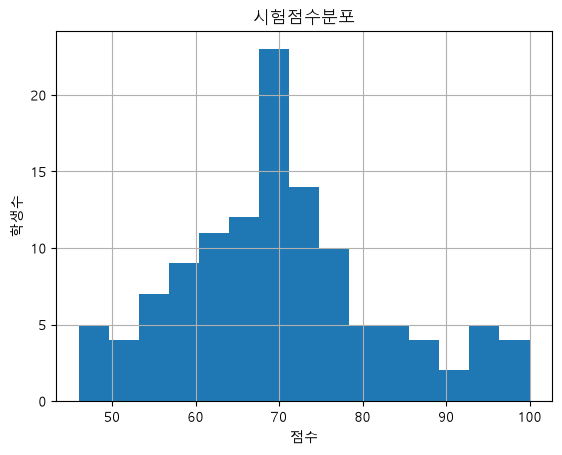

In [6]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

df['시험점수'].hist(bins=15)
plt.title("시험점수분포")
plt.xlabel("점수")
plt.ylabel("학생수")
plt.show()

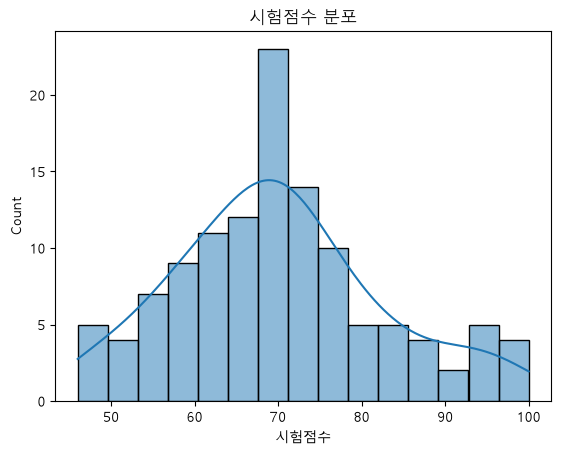

In [ ]:
###
import seaborn as sns

sns.histplot(df['시험점수'], # histplot 함수안에 컬럼 지정 시 분포도 등 출력
               bins=15,
               kde=True)
plt.title("시험점수 분포")
plt.show()

### 박스 플롯 -> 이상치 보는 차트
- 사분위 수를 상자로, 이상치를 점으로 보여지는 차트
- 가운데 50% Q1 ~ Q3
- 수염 밖의 점 : 이상치 후보

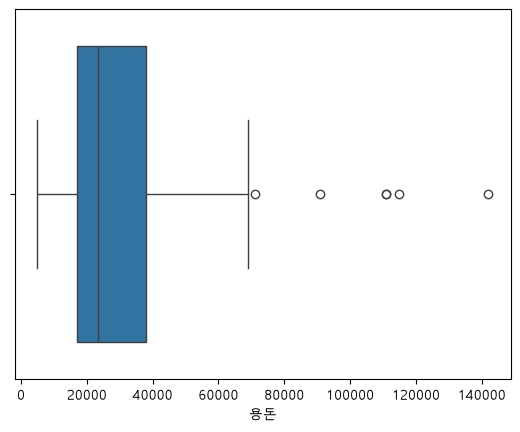

In [11]:
sns.boxplot(x=df['용돈'])
plt.show()

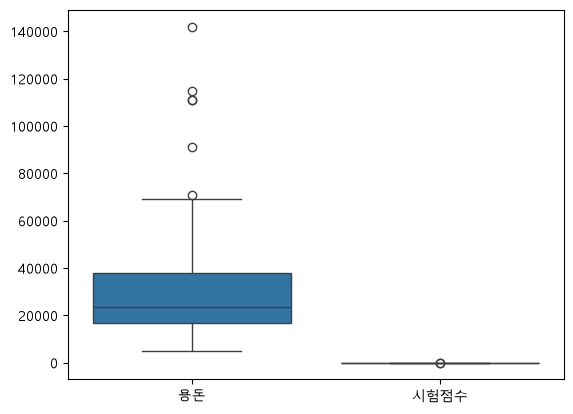

In [19]:
sns.boxplot(data=df[['용돈','시험점수']])
plt.show()

In [18]:
#이상치
Q1 = df['용돈'].quantile(0.25)
Q3 = df['용돈'].quantile(0.25)
print(Q1, Q3)
IQR = Q3 - Q1
print("IQR",IQR) 



17000.0 17000.0
IQR 0.0


In [ ]:
# 이상치


upper_bound = Q3 + 1.5*IQR
print(upper_bound)



17000.0


In [16]:
lower_bound = Q3 - 1.5*IQR
print(lower_bound)

17000.0


In [20]:
# 이상치 상한선 이상 데이터 확인



df[df['용돈'] > upper_bound]
# Q1 = df['용돈'].quantile(0,25)
# Q1 = df['용돈'].quantile(0,25)

,반,성별,공부시간,시험점수,용돈
1,A,남,1.8,69,23000
2,C,남,3.5,74,27000
4,A,여,3.2,64,25000
5,A,여,2.5,67,27000
6,C,남,1.3,65,36000
...,...,...,...,...,...
111,B,여,4.5,77,47000
112,A,여,2.0,69,23000
113,C,남,1.5,59,58000
116,A,남,5.6,74,50000


### 이상치 탐지

- 사기거래, 불량품, 이상 징후 발견
- 카드사의 보통 평소와 다른 큰 금액 결제, 출금

### 무조건 삭제가 아니다
- 진짜 중요한 시간대
- 이벤트 발생
- 이상치에 대해서는 적합한 사유 확인이 필수

In [ ]:
# 박스플롯 그리기 - 공부시간
# 코덱스와 같이 - 다양한 옵션 체크
# 시각화 퀄리티 높이기 

In [21]:
import pandas as pd

df = pd.read_csv("../data/07-1_study_habits.csv") # r" " 사용으로 백슬래시 기능인 줄바꿈 무시 
df.head()

,반,성별,공부시간,시험점수,용돈
0,C,여,2.7,63,11000
1,A,남,1.8,69,23000
2,C,남,3.5,74,27000
3,C,여,2.0,74,6000
4,A,여,3.2,64,25000


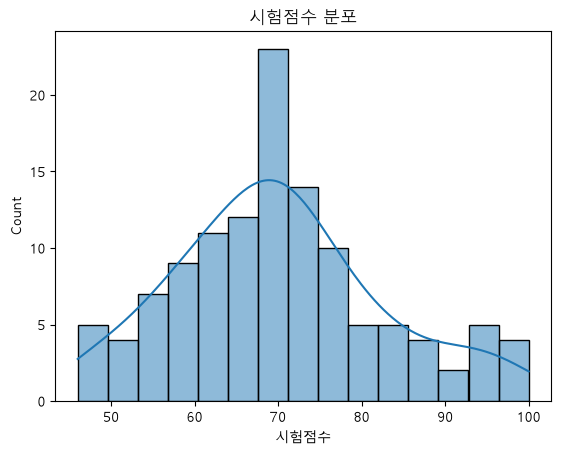

In [22]:
import seaborn as sns

sns.histplot(df['시험점수'], # histplot 함수안에 컬럼 지정 시 분포도 등 출력
               bins=15,
               kde=True)
plt.title("시험점수 분포")
plt.show()

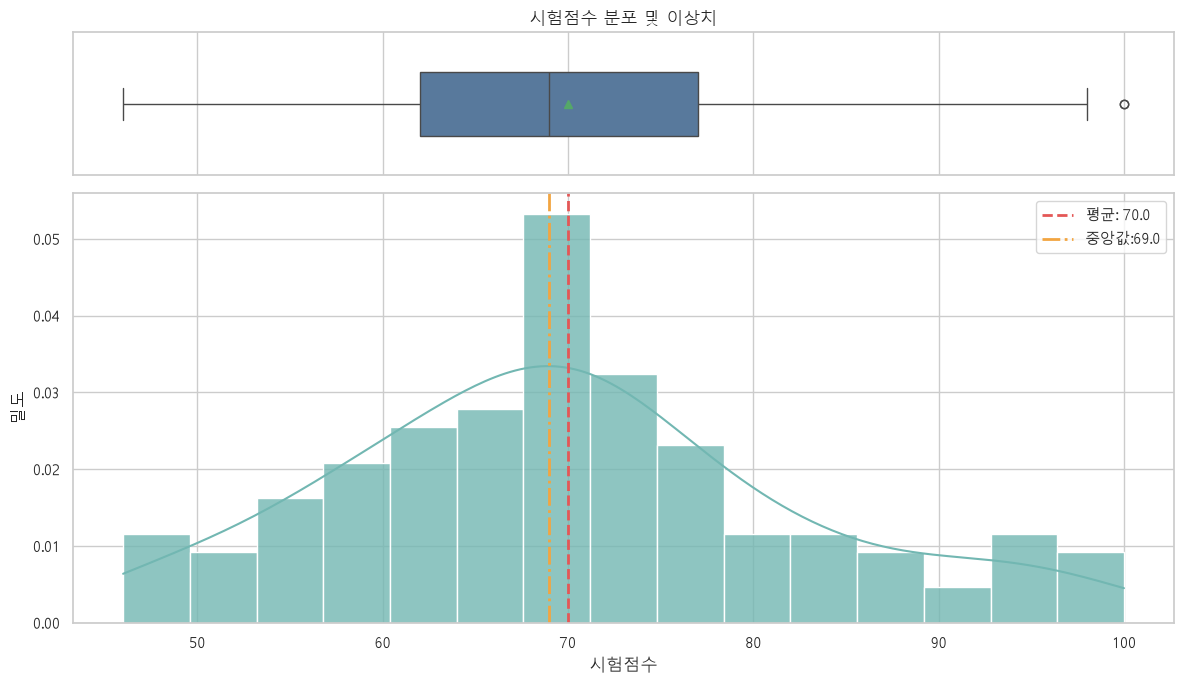

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
# plt.rcParams["font.family"] ="NanumGothic"
plt.rcParams["axes.unicode_minus"] =False


score = df["시험점수"].dropna()

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [1,
    3]}
)

sns.boxplot(
    x=score,
    ax=axes[0],
    color="#4C78A8",
    width=0.45,
    showmeans=True
)

axes[0].set_title("시험점수 분포 및 이상치")
axes[0].set_xlabel("")
axes[0].set_yticks([])

sns.histplot(
    score,
    bins=15,
    kde=True,
    stat="density",
    color="#72B7B2",
    edgecolor="white",
    alpha=0.8,
    ax=axes[1]
)

axes[1].axvline(
    score.mean(),
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"평균: {score.mean():.1f}"
)

axes[1].axvline(
    score.median(),
    color="#F2A541",
    linestyle="-.",
    linewidth=2,
    label=f"중앙값:{score.median():.1f}"
)

axes[1].set_xlabel("시험점수")
axes[1].set_ylabel("밀도")
axes[1].legend()

plt.tight_layout()
plt.show()


<Axes: xlabel='시험점수'>